# quant-demo — end-to-end pipeline

**Orchestration only.** Every number and chart below is produced by the project's
modules (`data/`, `features/`, `model/`, `backtest/`, `monitoring/`) — this notebook
just wires the stages together and displays the artifacts. All logic lives in the
modules; nothing is re-implemented here.

Each stage is **build-or-load with an immutable cache**, so a cold run builds the
caches once and every later run is near-instant. Randomness is seeded
(`config.SEED`) for bit-reproducibility.

1. `load_prices` · 2. `build_features` · 3. `run_walk_forward` ·
4. `daily_ic / icir` · 5. `build_weights / backtest` · 6. drift report

Presentation-ready charts are written to **`reports/`** as PNG/HTML for slides.

## TL;DR — what this is and how it does

**1 · What is the training set & evaluation set? What securities, what period?**
Daily **adjusted prices of the TWSE top-50** — the largest companies on the Taiwan
Stock Exchange by market cap (`.TW` tickers; 49 have full history). Raw prices span
**2014–2024**; features begin **Jan 2015** (after the 1-year warmup lookback).
Train/eval are split by **purged + embargoed walk-forward**, not a single cut:
- **Training set:** the feature panel **Jan 2015 → Dec 2024**, minus the purge+embargo
  halo around each test fold (so no overlapping-label leakage).
- **Evaluation set (out-of-sample test):** **Jul 2016 → Dec 2024** — every (date,
  ticker) predicted exactly once by a model that never saw it. All reported metrics
  (IC, Sharpe, drift) are computed on **this** out-of-sample period only.

*Known caveat: it's today's top-50 list → survivorship bias.*

**2 · Which features does LightGBM consider important?**
No single feature dominates (healthy — no leakage artifact). Top by gain importance:
`beta_63` (9.7%), `ret_skew_63` (9.4%), `dist_sma200` (8.9%), `mom_6_1` (8.3%),
`amihud_21` (7.9%), `dollar_vol_21` (7.5%), `vol_63` (7.2%), `mom_12_1` (5.9%).
→ a balanced mix of **beta, return-shape, trend, momentum, liquidity, volatility**.

**3 · Trading strategy, benchmark, and how it compares?**
- **Strategy:** cross-sectional, **dollar-neutral, sector-neutral, equal-weight
  quintile long-short** — long the top 10 / short the bottom 10 by predicted rank,
  rebalanced every 5 days, with 30 bps round-trip costs. A realistic, shortable
  **long-only top-quintile** variant is also run.
- **Benchmark:** **buy-and-hold the universe** (equal-weight top-50; TAIEX as a
  second reference), over the same Jul 2016 – Dec 2024 evaluation window.
- **Result (net of costs, out-of-sample):**

  | strategy | Sharpe (net) | ann. return |
  | --- | --- | --- |
  | Equal-weight buy-and-hold *(benchmark)* | **+1.29** | +19.0% |
  | TAIEX buy-and-hold *(benchmark)* | +0.80 | +13.1% |
  | Long-only top-quintile *(model)* | +0.70 | +13.8% |
  | Dollar-neutral long-short *(model)* | −1.36 | −9.6% |

  **The model does not beat simple buy-and-hold after costs** — and the benchmark is
  itself flattered by survivorship bias. The long-short's thin but real gross signal
  (IC ≈ 0.035) is eaten by turnover cost; the fix is a longer hold / signal smoothing,
  not a fancier model. **The deliverable is a rigorous, honest research loop** (purged
  validation, IC-first evaluation, gross-vs-net costs, drift monitoring) — not a
  deployable edge.

In [34]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

import config
from data import ingest
from features import alpha
from model import train
from backtest import metrics, portfolio, engine
from monitoring import drift
import run_pipeline  # reuse its seed helper — single source of truth
from IPython.display import Image, IFrame, display

run_pipeline._seed_everything(config.SEED)  # PYTHONHASHSEED + random + numpy
config.REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"seed={config.SEED} | universe={config.UNIVERSE} | reports -> {config.REPORTS_DIR}")

seed=42 | universe=TWSE_TOP50 | reports -> /Users/wanchuan/quant-demo/reports


## 1 · Data ingestion — `ingest.load_prices`

Adjusted daily OHLCV for the TWSE top-50, plus the TAIEX index proxy. Cached to
parquet and treated as immutable. The candlestick is a quick eyeball sanity check
on the headline name (TSMC, `2330.TW`).

In [35]:
prices = ingest.load_prices()
_index = ingest.load_index()
print(f"{len(prices):,} rows | {prices['ticker'].nunique()} tickers | "
      f"{prices['date'].min().date()} → {prices['date'].max().date()}")
prices.head()

131,369 rows | 49 tickers | 2014-01-02 → 2024-12-30


,date,ticker,open,high,low,close,volume
0,2014-01-02,1101.TW,19.488240,19.530651,19.191358,19.254974,11097643.0
1,2014-01-03,1101.TW,19.127740,19.127740,18.873270,18.894476,13527080.0
2,2014-01-06,1101.TW,19.064125,19.064125,18.491566,18.491566,15866789.0
3,2014-01-07,1101.TW,18.576384,18.746033,18.555178,18.724825,15749871.0
4,2014-01-08,1101.TW,18.746041,18.852069,18.512775,18.618805,20160107.0


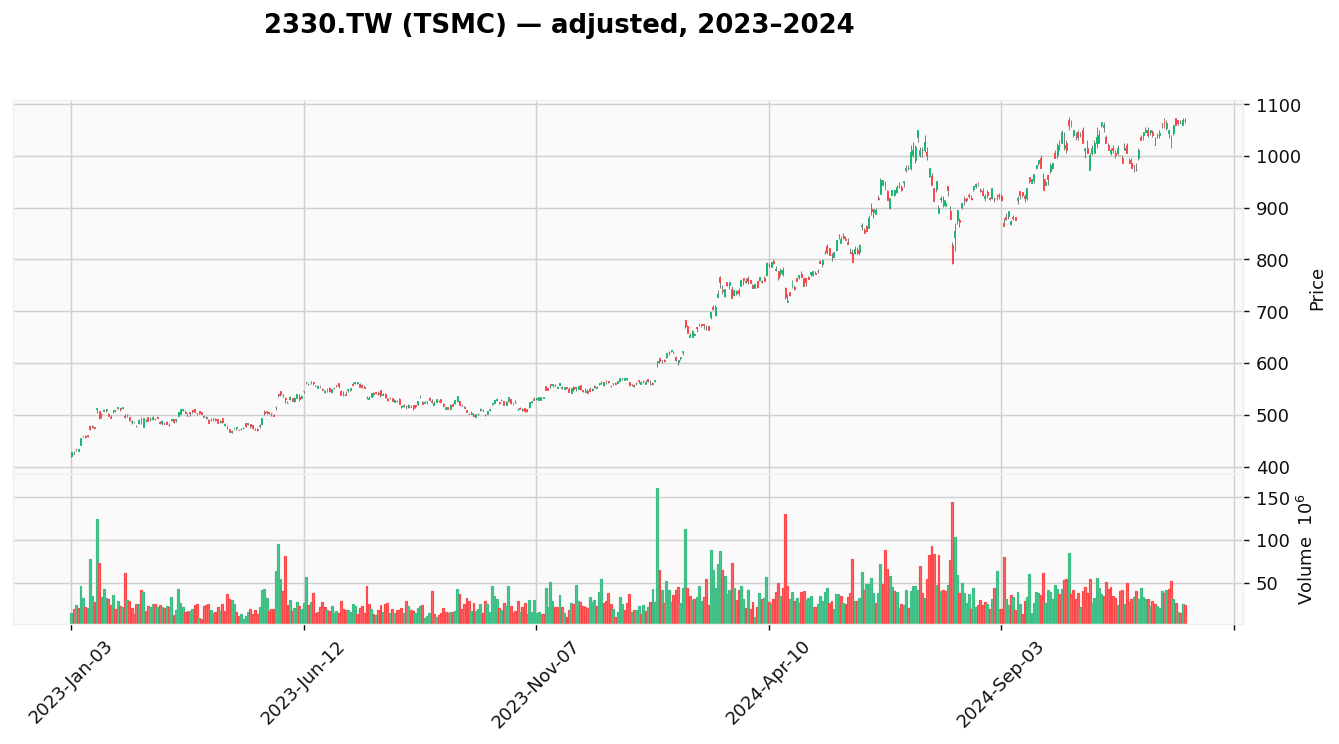

In [36]:
import mplfinance as mpf

tsmc = (prices[prices["ticker"] == "2330.TW"]
        .set_index("date")[["open", "high", "low", "close", "volume"]]
        .loc["2023":"2024"])
price_png = config.REPORTS_DIR / "price_overview_2330.png"
mpf.plot(tsmc, type="candle", volume=True, style="yahoo", figratio=(16, 7),
         title="2330.TW (TSMC) — adjusted, 2023–2024",
         savefig=dict(fname=price_png, dpi=130, bbox_inches="tight"))
display(Image(str(price_png)))

## 2 · Feature engineering — `alpha.load_features`

~18 point-in-time features (momentum, reversal, realized vol, liquidity, trend,
beta), each **cross-sectionally z-scored within every date** so the model trades
on "how a stock looks vs its peers today", not absolute levels.

In [37]:
feats = alpha.load_features()
feature_cols = alpha.feature_columns(feats)
print(f"{len(feats):,} rows | {len(feature_cols)} features (z-scored daily)")
feats[["date", "ticker", "sector"] + feature_cols[:5]].head()

109,519 rows | 18 features (z-scored daily)


,date,ticker,sector,mom_12_1,mom_6_1,rev_5,rev_21,vol_21
0,2015-01-09,1101.TW,Materials,-0.484626,0.151066,-0.955073,-1.438347,-0.559180
1,2015-01-09,1216.TW,ConsumerStaples,-0.674290,-0.513188,-0.047871,-0.128447,-0.081293
2,2015-01-09,1301.TW,Materials,-1.048724,-0.910367,-0.046151,0.210886,0.854777
3,2015-01-09,1303.TW,Materials,-0.775897,-1.018995,-0.438598,-0.288445,0.909737
4,2015-01-09,1326.TW,Materials,-1.274796,-0.689472,-0.924972,-0.758196,0.599879


## 3 · Purged walk-forward model — `train.load_predictions`

LightGBM trained across **purged + embargoed** walk-forward folds (overlapping
10-day labels can't leak across the train/test boundary). Every (date, ticker) is
predicted exactly once, out-of-sample, by a model that never saw its label window.

In [38]:
preds = train.load_predictions()
print(f"{len(preds):,} OOS predictions | {preds['date'].nunique()} dates | "
      f"{preds['date'].min().date()} → {preds['date'].max().date()}")
preds.head()

97,320 OOS predictions | 1987 dates | 2016-07-15 → 2024-12-16


,date,ticker,pred,fwd_ret,fwd_rank,sector
0,2016-07-15,1101.TW,0.057555,-0.000140,-0.061224,Materials
1,2016-07-15,1216.TW,0.027547,-0.012121,-0.510204,ConsumerStaples
2,2016-07-15,1301.TW,0.066261,-0.007653,-0.387755,Materials
3,2016-07-15,1303.TW,0.031817,-0.005527,-0.306122,Materials
4,2016-07-15,1326.TW,0.066433,0.008495,0.183673,Materials


## 4 · Signal quality — `metrics.daily_ic` / `icir`

Lead with IC, not PnL: with 50 names the portfolio is high-variance, but the IC
aggregates every name every day. Note the **overlap-adjusted ICIR** — daily ICs
share 9/10 of their label window, so the naive √252 figure is inflated.

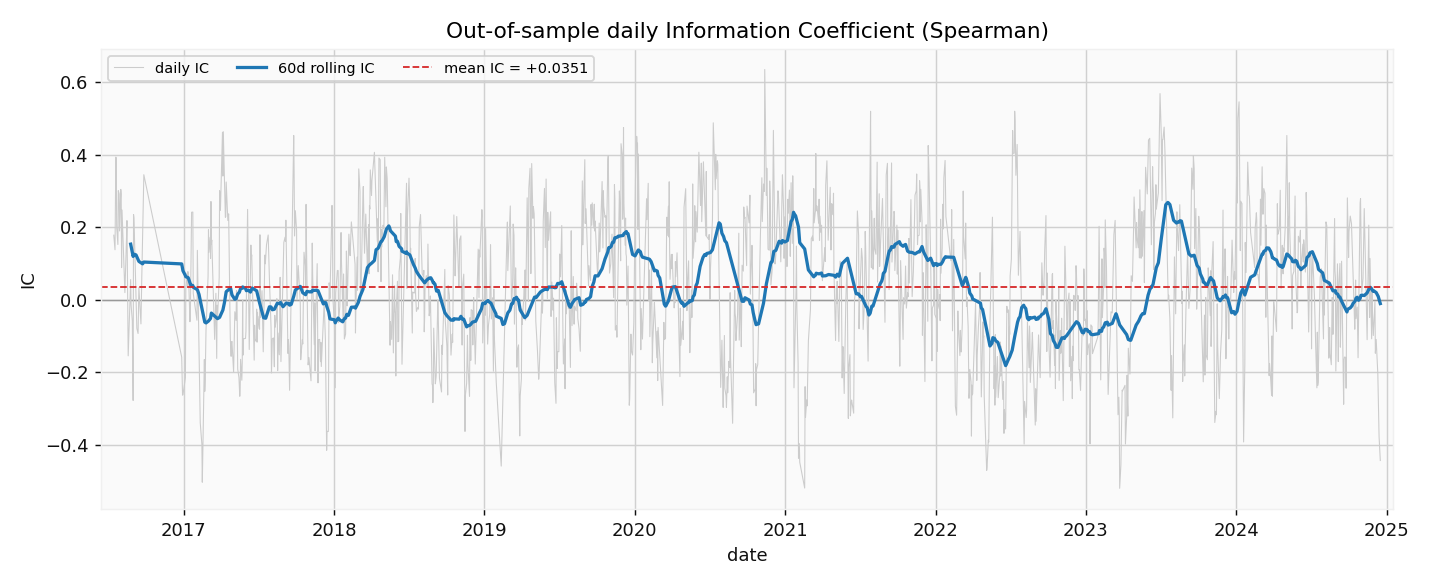

,value
n_days,1987.000000
mean_ic,0.035149
ic_std,0.191242
icir_ann,0.922644
icir_naive,2.917656
ic_autocorr,0.818209
ic_tstat,8.192807
hit_rate,0.559134


In [39]:
ic = metrics.daily_ic(preds)
ic_stats = metrics.summarize_ic(ic)
display(Image(str(metrics.plot_rolling_ic(ic))))
pd.Series(ic_stats).to_frame("value")

## 5–6 · Portfolio + cost-aware backtest — `portfolio.build_weights` / `engine.backtest`

Dollar-neutral, equal-weight quintile long-short (sector-neutralized), rebalanced
every 5 days through our own vectorized engine with `COST_BPS` turnover costs. The
**gross-vs-net gap is the honesty proof**; the long-only top-quintile is the
realistic, shortable deployment.

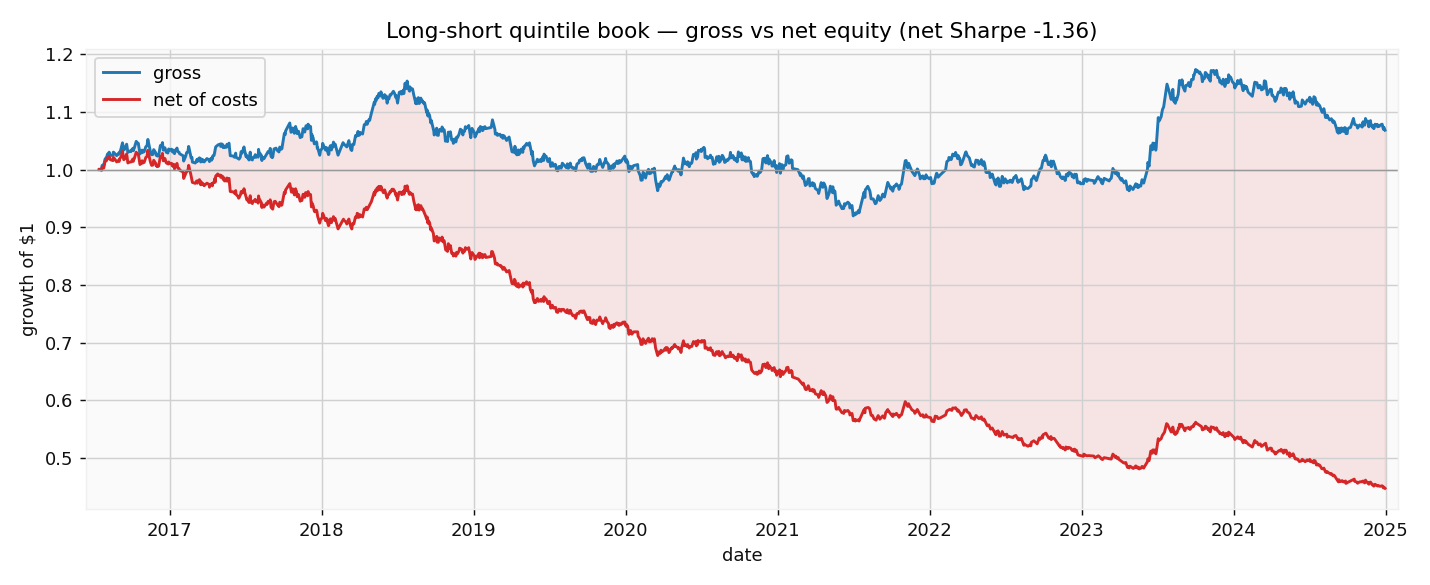

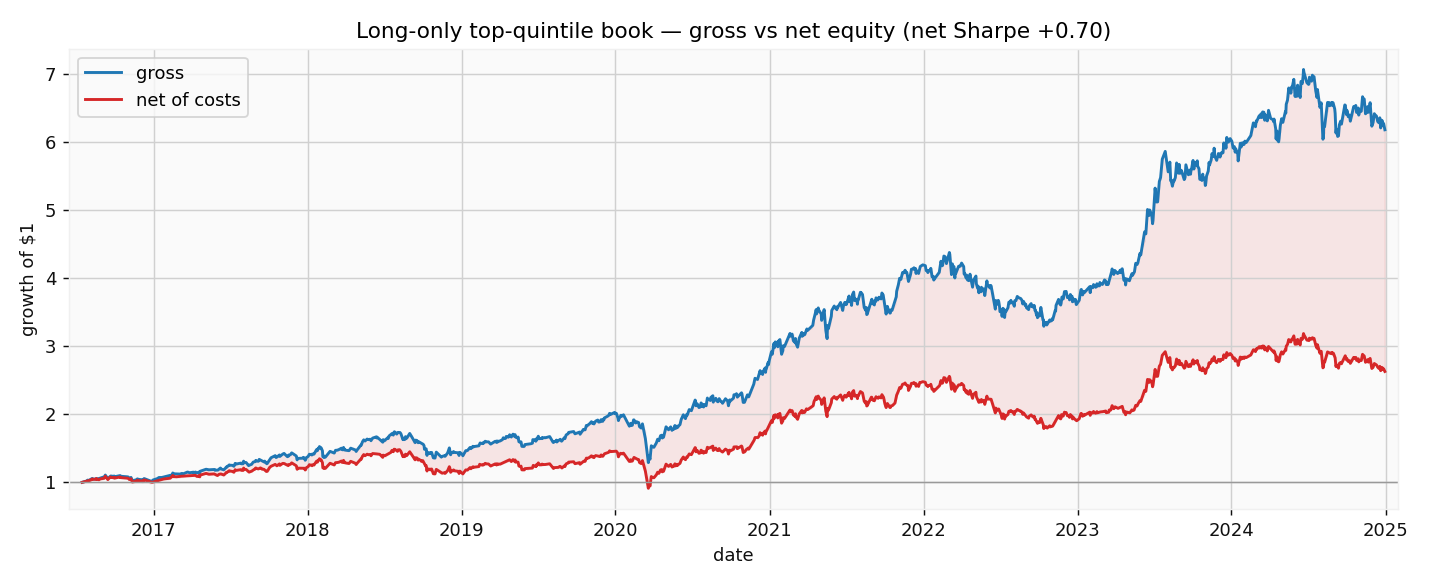

In [40]:
rets = engine.daily_returns(prices)
w_ls = portfolio.build_weights(preds, long_only=False)
w_lo = portfolio.build_weights(preds, long_only=True)
res_ls = engine.backtest(w_ls, rets)
res_lo = engine.backtest(w_lo, rets)

display(Image(str(engine.plot_equity(res_ls, title="Long-short quintile book"))))
display(Image(str(engine.plot_equity(
    res_lo, path=config.REPORTS_DIR / "equity_long_only.png",
    title="Long-only top-quintile book"))))

## 7 · Drift monitoring — `drift.run_monitoring`

The three-ring framework: **(1) performance** — rolling 60-day IC; **(2) input
drift** — PSI/KS per *raw* feature, early vs late (cross-sectional z-scoring hides
level drift, so we monitor the raw features); **(3) regime** — a realized-vol
percentile flag. The batch artifact is an Evidently report at `reports/drift.html`.

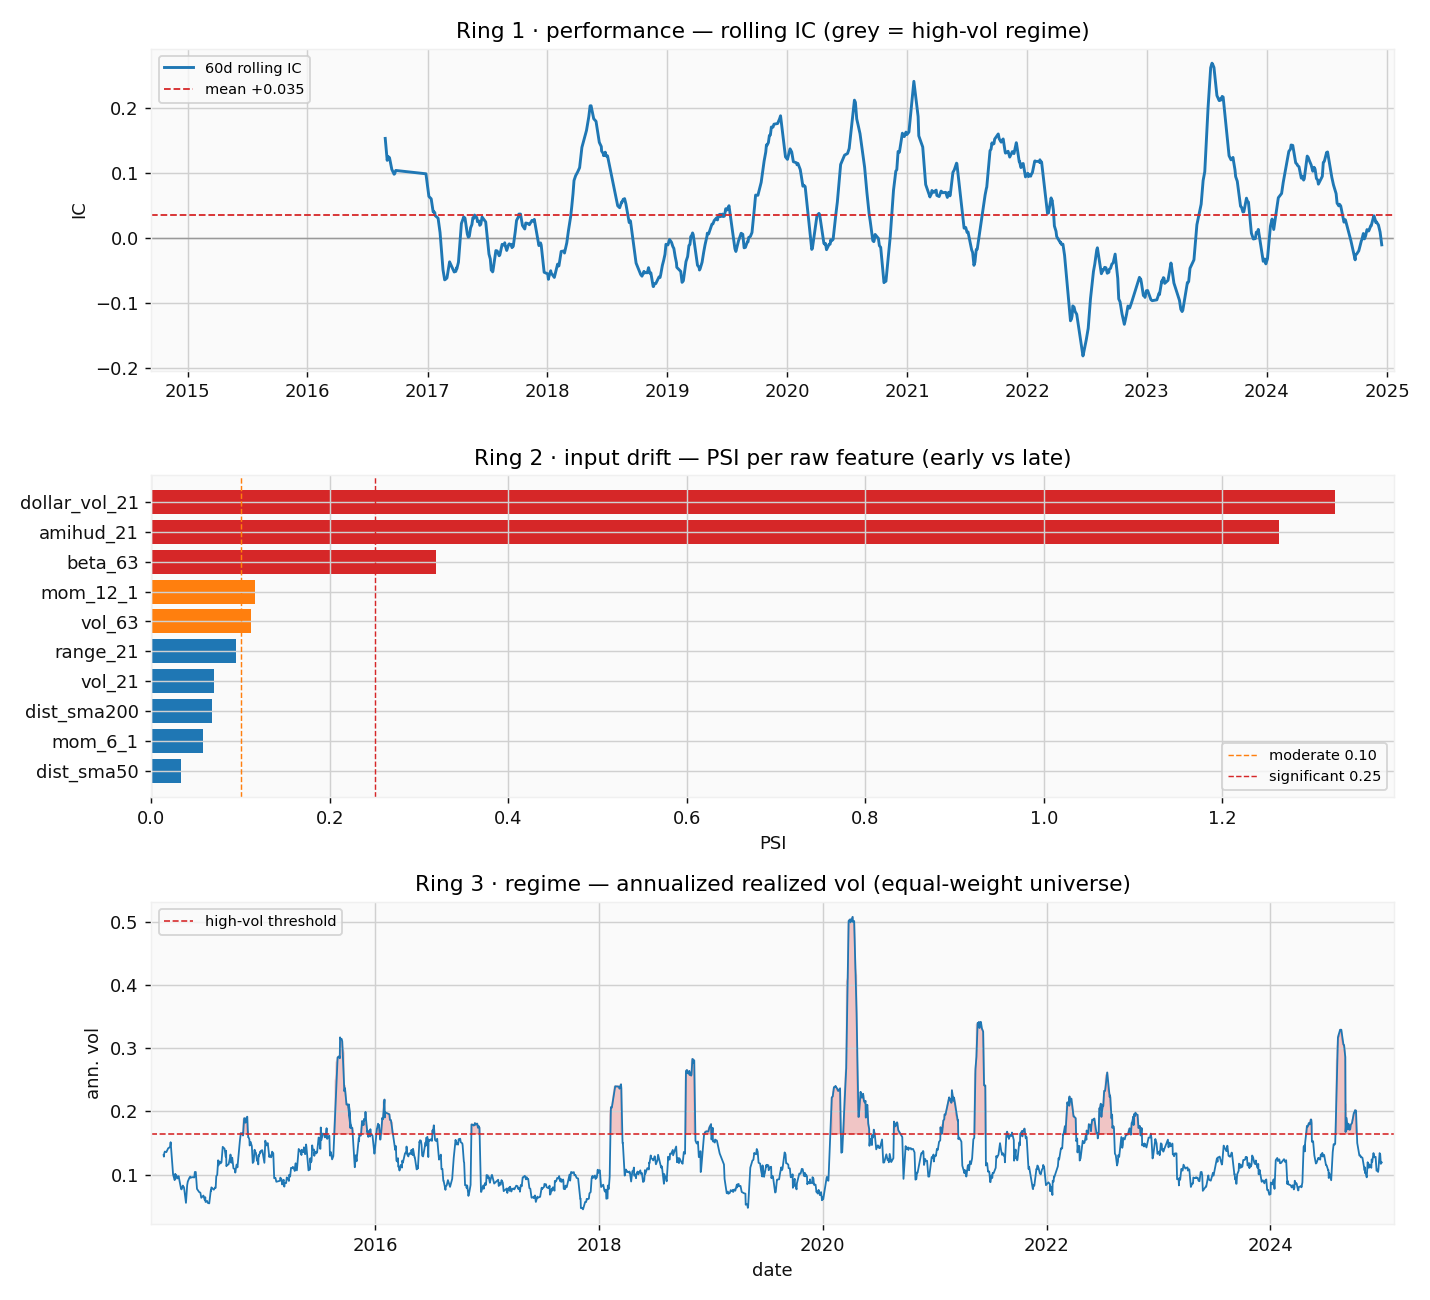

,feature,psi,ks_stat,ks_pvalue,drift
0,dollar_vol_21,1.326071,0.414947,0.000000e+00,significant
1,amihud_21,1.263481,0.412157,0.000000e+00,significant
2,beta_63,0.319167,0.247106,0.000000e+00,significant
3,mom_12_1,0.116389,0.081941,6.239216e-106,moderate
4,vol_63,0.111979,0.103748,1.047946e-169,moderate
5,range_21,0.094954,0.093139,8.520942e-137,stable
6,vol_21,0.070186,0.091231,2.962987e-131,stable
7,dist_sma200,0.068268,0.080668,1.128657e-102,stable


In [41]:
raw = alpha.build_raw_features(prices)
mon = drift.run_monitoring(predictions=preds, raw_features=raw,
                           returns=rets, make_html=True)
display(Image(str(mon["monitoring_png"])))
mon["drift"].head(8)

## Results summary — the slide

One clean table of every headline number, assembled from the stage outputs above.

In [43]:
signal = pd.DataFrame({
    "metric": ["mean daily IC", "ICIR (overlap-adj)", "ICIR (naive √252)",
               "IC t-stat", "IC hit rate"],
    "value": [f"{ic_stats['mean_ic']:+.4f}", f"{ic_stats['icir_ann']:+.2f}",
              f"{ic_stats['icir_naive']:+.2f}", f"{ic_stats['ic_tstat']:+.2f}",
              f"{ic_stats['hit_rate']:.1%}"],
    "sanity band": ["0.01–0.04", "0.5–2.0", "(inflated)", "—", "—"],
})
display(signal)

def _row(name, r):
    return {"strategy": name, "Sharpe gross": round(r["sharpe_gross"], 2),
            "Sharpe net": round(r["sharpe_net"], 2), "ann ret": f"{r['ann_return']:+.1%}",
            "vol": f"{r['ann_vol']:.1%}", "max DD": f"{r['mdd']:+.1%}",
            "Calmar": round(r["calmar"], 2), "turnover/rebal": f"{r['avg_turnover']:.1%}",
            "hit": f"{r['hit_rate']:.1%}"}

backtest_tbl = pd.DataFrame([_row("long-short (ideal)", res_ls),
                             _row("long-only (real)", res_lo)]).set_index("strategy")
display(backtest_tbl)

,metric,value,sanity band
0,mean daily IC,+0.0351,0.01–0.04
1,ICIR (overlap-adj),+0.92,0.5–2.0
2,ICIR (naive √252),+2.92,(inflated)
3,IC t-stat,+8.19,—
4,IC hit rate,55.9%,—


,Sharpe gross,Sharpe net,ann ret,vol,max DD,Calmar,turnover/rebal,hit
strategy,,,,,,,,
long-short (ideal),0.15,-1.36,-9.6%,7.0%,-56.7%,-0.17,72.7%,46.3%
long-only (real),1.23,0.70,+13.8%,19.8%,-38.6%,0.36,72.1%,53.5%


In [44]:
artifacts = sorted(p.name for p in config.REPORTS_DIR.glob("*") if p.suffix in {".png", ".html"})
print("Slide-ready artifacts in reports/:")
for a in artifacts:
    print("  •", a)

Slide-ready artifacts in reports/:
  • drift.html
  • equity_gross_net.png
  • equity_long_only.png
  • monitoring.png
  • price_overview_2330.png
  • rolling_ic.png


**Honest read.** A modest, real cross-sectional signal (mean IC ≈ 0.035, ICIR ≈ 0.9
overlap-adjusted, IC stable over time). The long-short **net** Sharpe is eaten by
~10%/yr turnover cost — the fix is a longer hold / signal smoothing, *not* a fancier
model. The long-only top-quintile (net Sharpe ≈ 0.7) is the realistic, shortable
deployment. Known limitations — survivorship bias, concentration, short availability
— are named in the README, not hidden.